# Clustering
trovare strutture o somiglianze nel dataset etichettando i dati.

parametri:
* `min_pts`: numero minimo di punti che formano un cluster
*  `eps`: distanza massima per cui due punti sono considerati vicini

definizione:
* `core point`: un punto che ha almeno `min_pts` in un suo intorno `eps`
* `border point`: un punto che non e' `core point` ma che e' vicino ad ud un core
* `noise point`: tutti gli altri non classificabili sono detti `noise`.

### raggiungibilita
* $p$ *raggiungibile **direttamente** per densita* da $q$: se $q$ e' core ed $p$ e' vicino di $q$, duqnue $q$ appartiene ad un cluster.
* $p$ *raggiungibile per densita* da $q$: se esiste una catena di core point a partire da $q$, con $q$ **core** (nel senso che sono tutti vicini tra loro) che mi portano a $p$. *tutti i punti della catena fanno parte di un'unico cluster*
* i punti $p$ e $q$ sono connessi per densita, ossia raggiungibili l'uno dall'altro se sono collegati con $p$ e $q$ non **core**, ossia esiste $r$ per cui $p$ e $q$ raggiungibili per densita da $r$ (???)

### cluster
$C$ cluster su `min_pts` e `eps` deve essere non vuoto e soddisfare:
1. Per ogni $p,q$, se $q$ in $C$, se $p$ e' raggiungibile per densita da $q$, allora $p$ appartiene a $C$.
2. Per ogni $p,q$, queste sono connesse per densita, ossia da un core in $C$.

**border**: per definizione possono appartenere a piu cluster, poiche raggiungibili da piu' core.


## L'Algoritmo

- INPUT: un insieme `D` di `n` punti, `eps`, `min_pts`
- OUTPUT: per ogni punto `p` in `D`, un valore `label[p]` in `{Noise, 0, 1, ...}`

* Inizializzazione: `label[p] ← non_visitato` per tutti i punti `p`
* Per ogni punto `p` in `D` etichettato `non_visitato`:
    1. Sia `N` l'insieme dei punti a distanza `≤ eps` da `p`
    2. Se `|N| < min_pts`, non è un core point, ma potrebbe diventare border. Per il momento
        - `label[p] ← Noise`
    3. Altrimenti `p` è un core di un nuovo cluster `c`, quindi
        * `label[p] ← c`
        * `S ← N - {p}`
        * Prosegui prelevando punti `q` da `S` fino ad esaurimento di quest'ultimo
            - Se `q` è già in un cluster, scartalo (se `label[q]` è un numero)
            - `label[q] ← c` anche se valeva `Noise`
            - Se `q` è un core point
                - Definisci `N` come l'insieme dei vicini di `q`
                - `S ← S ∪ (N - {q})`

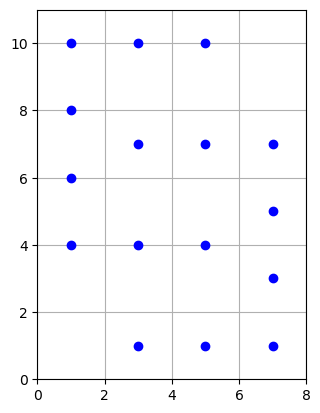

In [3]:
import matplotlib.pyplot as plt
import numpy as np

points =  [(3,1), (5,1), (7,1), (7,3), (7,5), (7,7), (5,7), (3,7),
           (5,4), (3,4), (1,4), (1,6), (1,8), (1,10), (3,10), (5,10)]

fig, ax = plt.subplots(1, 1)

ax.scatter([x for x, _ in points], [y for _, y in points], color='blue', marker='o', zorder=3)

ax.set_xlim(0, 8)
ax.set_ylim(0, 11)
# prova a togliere per vedere la differenza
ax.set_aspect('equal')
ax.grid(True)
#ax.axis('off')
plt.show()

# dbscan
* `KDTree.query_ball_points(p,eps)`: ritorna i punti a distanza al piu eps da p nell'albero KDTree.

In [4]:
from scipy.spatial import KDTree

def dbscan(points, eps, min_pts):
    '''
    points: Una sequenza di punti, o qualsiasi struttura che possa essere interpretata coma una sequenza di punti
    eps: distanza massima per essere considerato vicino
    min_pts: numero di punti minimo di vicini per essere considerato core

    Ritorna una lista label tale che labels[i] in ('Noise', '0', '1', '2', '3',...) e descrive il cluster a cui appartiene il points[i]
    '''
    points = np.array(points)

    n = points.shape[0]
    tree = KDTree(points)

    c = -1  # c+1 sarà il 'nome' del prossimo cluster
    labels = [None]*n # None = non visitato

    # i: per indicizzare i punti in labels
    for i, p in enumerate(points):
        if labels[i] != None: # gia visitato
            continue
        N = tree.query_ball_point(p, eps) # indici in points dei punti a distanza eps da p
        
        # per ora il nodo i e' noise, non so se e' border magari
        if len(N) < min_pts:
            labels[i] = 'Noise'
            continue

        # altrimenti ho un cluster!
        c += 1

        labels[i] = str(c)

        # estensione: visita tutti i nodi raggiungibili da 
        S = set(N) - set([i]) # nel caso medio |N| è considerato costante
        while len(S) > 0:
            j = S.pop()
            if labels[j] == 'Noise': # non core
                labels[j] = str(c)
            if labels[j] != None: # se era gia stato etichettato non faccio nulla 
                continue

            # se label == None, mettilo nel mio cluster
            labels[j] = str(c)
            N = tree.query_ball_point(points[j], eps)
            if len(N) < min_pts:
                continue
            # se il nodo e' core a sua volta, allora aggiungi i suoi vicini all'estensione
            S.update( set(N) - set([j]) )

    return labels



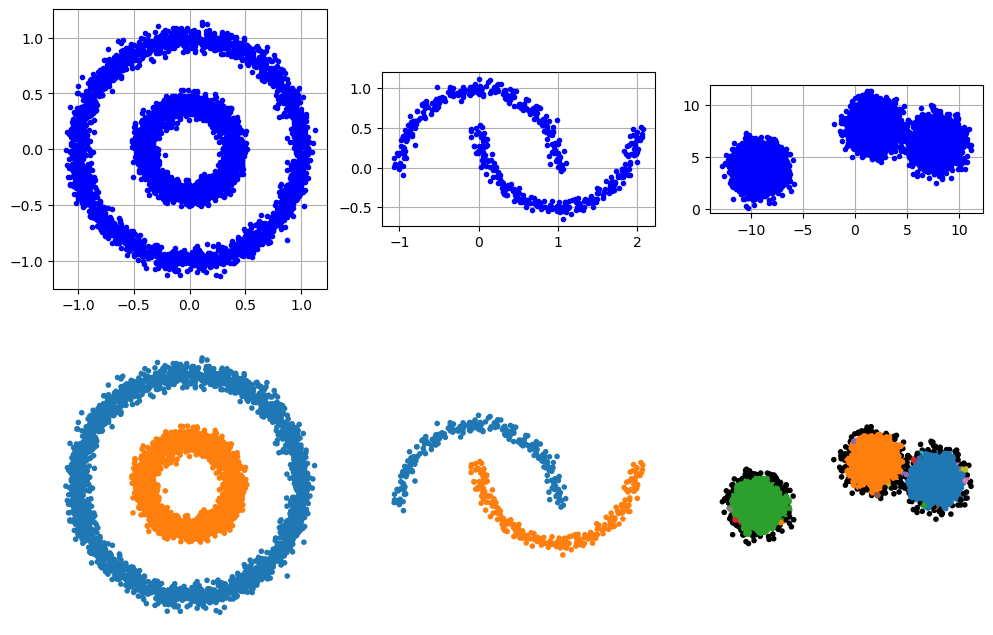

In [5]:
from sklearn import datasets
import matplotlib.colors as mcolors

# con scikit posso generare: cerchi concentrici, mezzelune, blob di punti
noisy_circles = datasets.make_circles(n_samples=5000, factor=0.4, noise=0.05, random_state=0)
noisy_moons = datasets.make_moons(n_samples=500, noise=0.05, random_state=0)
blobs = datasets.make_blobs(n_samples=15000, center_box=(-10,10), random_state=20)

# crea una matrice 2x3 di plot da visualizzare
fig, axs = plt.subplots(2, 3, figsize=(12,8))

for i, the_dataset in enumerate([noisy_circles, noisy_moons, blobs]): 
    points = the_dataset[0]
    ax = axs[0][i] # iteriamo sulla prima riga di grafici
    ax.scatter([x for x, _ in points], [y for _, y in points], color= 'blue', marker='.', zorder=3)
    ax.grid(True)
    ax.set_aspect('equal')
    #ax.axis('off')

color_map = list(mcolors.TABLEAU_COLORS.keys())*10

for i, the_dataset in enumerate([noisy_circles, noisy_moons, blobs]): 
    points = the_dataset[0]
    labels = dbscan(points, eps=0.2, min_pts=4)
    ax = axs[1][i] # iteriamo sulla seconda riga
    colors = []
    for lab in labels:
        # il noise e nero
        if lab == 'Noise':
            colors.append('black')
        else:
            colors.append(color_map[int(lab)])
    ax.scatter([x for x, _ in points], [y for _, y in points], color=colors, marker='.', zorder=3)
    ax.grid(True)
    ax.set_aspect('equal')
    ax.axis('off')

# stimare epsilon
 
Per stimare il valore ottimale di `eps`, a ogni punto `p` si associa la distanza dal punto più lontano tra i suoi `min_pts` vicini. Le distanze così ottenute vengono ordinate in ordine crescente, ottenendo una curva che cresce lentamente all’inizio e poi aumenta bruscamente.

* ci sono zone in cui i punti sono densi
* verso il `gomito` ci sono zone piu' sparse

il migliore eps e' il punto di gomito:
* siano `A` e `B` gli estremi della curva disegnata
* disegna la retta tra `A` e `B`
* il gomito e' il punto `C` piu lontano dalla retta